<a href="https://colab.research.google.com/github/SonalShukla-projects/Bankruptcy_Prediction_Company_ML_Project/blob/main/notebooks/04_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/ML_DATASETS/clean_bankruptcy_data.csv"
df=pd.read_csv(path)

In [ ]:
X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

0.9633431085043989 1.0 0.0196078431372549 0.038461538461538464


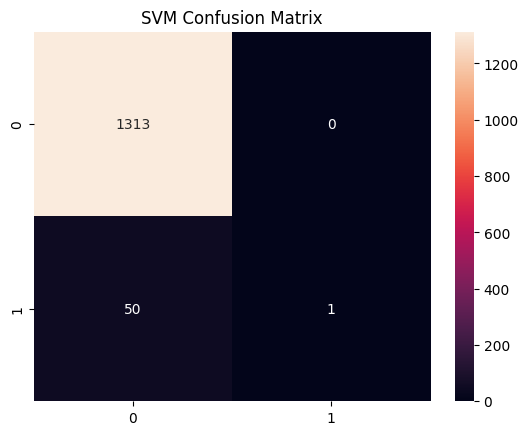

In [ ]:
from sklearn.svm import SVC

model = SVC()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print(accuracy,precision,recall,f1)

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d')
plt.title("SVM Confusion Matrix")
plt.show()

results = pd.DataFrame({
    "Model":["SVM"],
    "Accuracy":[accuracy],
    "Precision":[precision],
    "Recall":[recall],
    "F1":[f1]
})

import os

base_path = "/content/drive/MyDrive/ML_Project_Results"
os.makedirs(base_path, exist_ok=True)

results.to_csv(f"{base_path}/svm_results.csv", index=False)

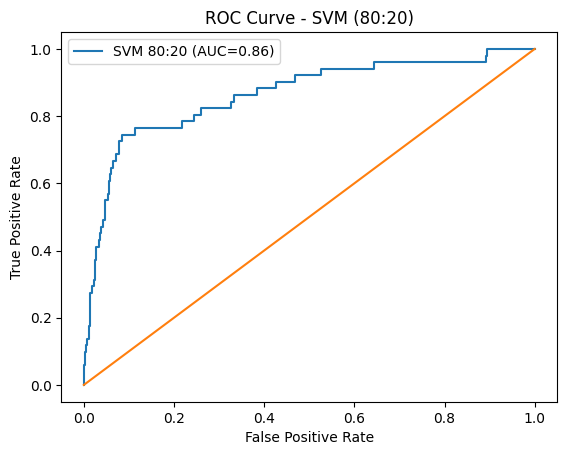

In [ ]:
from sklearn.metrics import roc_curve, auc

# ROC Curve
y_score = model.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"SVM 80:20 (AUC={roc_auc:.2f})")
plt.plot([0,1], [0,1])

plt.title("ROC Curve - SVM (80:20)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
# 70:30 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
from sklearn.svm import SVC

model = SVC()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("SVM 70:30")
print(accuracy, precision, recall, f1)

results = pd.DataFrame({
    "Model": ["SVM"],
    "Split": ["70:30"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1]
})




SVM 70:30
0.9618768328445748 0.0 0.0 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


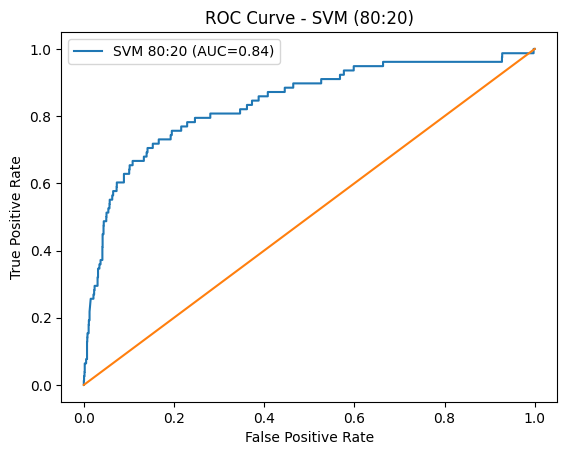

In [ ]:

# ROC Curve
y_score = model.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"SVM 80:20 (AUC={roc_auc:.2f})")
plt.plot([0,1], [0,1])

plt.title("ROC Curve - SVM (80:20)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
pip install imblearn

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Instantiate SMOTE
sm = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape}, {y_train.shape}")
print(f"Resampled training set shape: {X_train_res.shape}, {y_train_res.shape}")
print(f"Class distribution after SMOTE:\n{y_train_res.value_counts()}")

Original training set shape: (4773, 95), (4773,)
Resampled training set shape: (9262, 95), (9262,)
Class distribution after SMOTE:
Bankrupt?
0    4631
1    4631
Name: count, dtype: int64


SVM with SMOTE - 70:30 Split
Accuracy: 0.8919843597262952
Precision: 0.2033195020746888
Recall: 0.6282051282051282
F1 Score: 0.3072100313479624


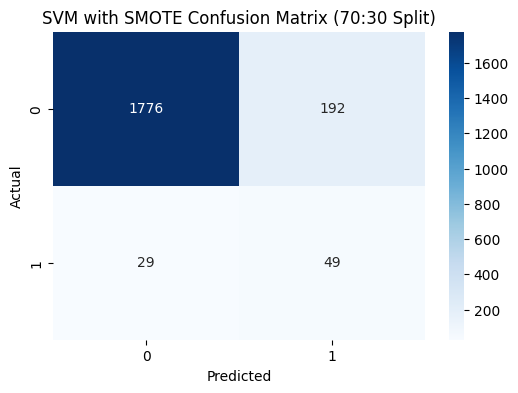

In [ ]:
# Train a new SVM model on the SMOTE-resampled data
model_smote = SVC(random_state=42)
model_smote.fit(X_train_res, y_train_res)

# Make predictions on the original (unresampled) test set
y_pred_smote = model_smote.predict(X_test)

# Evaluate the model
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote, zero_division=0)
recall_smote = recall_score(y_test, y_pred_smote, zero_division=0)
f1_smote = f1_score(y_test, y_pred_smote, zero_division=0)

print("SVM with SMOTE - 70:30 Split")
print(f"Accuracy: {accuracy_smote}")
print(f"Precision: {precision_smote}")
print(f"Recall: {recall_smote}")
print(f"F1 Score: {f1_smote}")

# Confusion Matrix
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues')
plt.title("SVM with SMOTE Confusion Matrix (70:30 Split)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

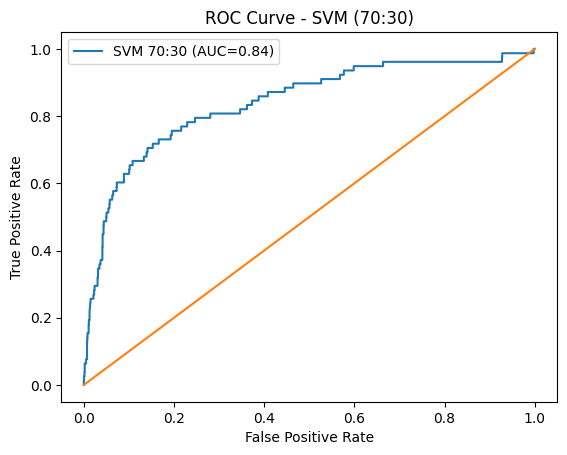

In [ ]:

# ROC Curve
y_score = model.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"SVM 70:30 (AUC={roc_auc:.2f})")
plt.plot([0,1], [0,1])

plt.title("ROC Curve - SVM (70:30)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
# Store results in a DataFrame and save to CSV
results_smote = pd.DataFrame({
    "Model": ["SVM + SMOTE"],
    "Split": ["70:30"],
    "Accuracy": [accuracy_smote],
    "Precision": [precision_smote],
    "Recall": [recall_smote],
    "F1": [f1_smote]
})

results.to_csv(f"{base_path}/svm_smote_70_30.csv", index=False)
display(results_smote)

,Model,Split,Accuracy,Precision,Recall,F1
0,SVM + SMOTE,70:30,0.891984,0.20332,0.628205,0.30721
